In [2]:
# %pip freeze > requirements.txt
# %pip install -r requirements.txt

# 1. Initiation


#### 1.1 Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats

#### 1.2 Importing Daataset

In [ ]:
Dataset = pd.read_excel('Combined_Coordinate.xlsx')

#### 1.3 Max and Min Values of Variables

In [ ]:
# Print the max and min value of every variable after removing outliers
max_values = Dataset.max()  # Maximum values of each column
min_values = Dataset.min()  # Minimum values of each column

# Printing the results
print("Maximum values of each variable after removing outliers:")
print(max_values)

print("\nMinimum values of each variable after removing outliers:")
print(min_values)

Maximum values of each variable after removing outliers:
U1           0.000000
U2           0.035615
U3           0.050455
U4           0.061656
U5           0.070832
            ...      
Re     1000000.000000
Aoa         15.000000
Cl           1.762400
Cd           0.225310
Cm           0.068100
Length: 206, dtype: float64

Minimum values of each variable after removing outliers:
U1         0.000000
U2         0.008559
U3         0.011854
U4         0.014265
U5         0.016210
           ...     
Re     10000.000000
Aoa      -10.000000
Cl        -1.175700
Cd         0.000630
Cm        -0.113500
Length: 206, dtype: float64


#### 1.4 Input and Output Features

In [ ]:
# Input and Output Features
X = Dataset[[f"U{i}" for i in range(1, 101)] + [f"L{i}" for i in range(1, 101)] + ['Mach', 'Re', 'Aoa']]
y = Dataset[['Cl', 'Cd', 'Cm']]

#### 1.5 Split the Dataset: Train, Validation, and Test

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=0)        # 80% train
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)  # 10% val, 10% test

#### 1.6 Data Scaling : Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)                 
X_train = sc.transform(X_train)
X_val = sc.transform(X_val)
X_test = sc.transform(X_test)


In [ ]:
print (X_train)

[[ 0.         -0.69043468 -0.71919565 ... -1.37365532 -1.37365532
  -1.09057794]
 [ 0.         -0.09364569  0.35741952 ... -0.39955467 -0.39955467
   0.34828529]
 [ 0.         -0.8433374  -0.93771431 ... -1.6867591  -1.6867591
   1.65011394]
 ...
 [ 0.          2.1166952   2.01578804 ...  0.95722838  0.95722838
   1.06771691]
 [ 0.          0.85289054  0.86535431 ... -1.06055154 -1.06055154
   1.3417861 ]
 [ 0.          0.85289054  0.86535431 ...  1.37470009  1.37470009
   0.72513043]]


In [ ]:
print (X_test)

[[ 0.         -1.40792992 -1.42681011 ...  1.06159631  1.06159631
  -1.33038848]
 [ 0.          0.74455581  0.69603326 ...  0.71370322  0.71370322
   1.23901015]
 [ 0.         -1.24268782 -1.29599977 ... -0.60829052 -0.60829052
   0.17699205]
 ...
 [ 0.         -0.40571136 -0.41241015 ... -0.9213943  -0.9213943
   0.69087178]
 [ 0.          2.1166952   2.01578804 ... -0.5387119  -0.5387119
  -1.09057794]
 [ 0.          0.85380466  0.8758127  ...  0.2614422   0.2614422
  -1.63871632]]


In [ ]:
print (X_val)

[[ 0.         -0.69043468 -0.71919565 ...  0.60933529  0.60933529
   0.03995746]
 [ 0.         -0.69043468 -0.71919565 ... -0.9213943  -0.9213943
  -1.63871632]
 [ 0.         -1.40792992 -1.42681011 ...  1.54864663  1.54864663
   0.31402665]
 ...
 [ 0.          0.85380466  0.8758127  ...  0.92243907  0.92243907
   0.82790637]
 [ 0.         -0.69043468 -0.71919565 ... -0.67786914 -0.67786914
  -1.43316443]
 [ 0.         -0.4512696  -0.48332417 ... -1.6867591  -1.6867591
   0.58809583]]


# 2. Train the Models and Save

#### 2.1  Deep Neural Networks

In [ ]:
# Custom R² Metric
import tensorflow.keras.backend as K

def coeff_determination(y_true, y_pred):
    SS_res = K.sum(K.square(y_true - y_pred))
    SS_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - SS_res / (SS_tot + K.epsilon())

# Build the ANN Model
dnn = tf.keras.models.Sequential()
dnn.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
dnn.add(tf.keras.layers.Dense(units=128, activation='relu'))
dnn.add(tf.keras.layers.Dense(units=128, activation='relu'))
dnn.add(tf.keras.layers.Dense(units=128, activation='relu'))
dnn.add(tf.keras.layers.Dense(units=3, activation='linear'))

# Compile the ANN MOdel
import keras
dnn.compile(optimizer = 'adam',
              loss      = keras.losses.mean_squared_error,
              metrics   = ['mean_absolute_error', 'mean_absolute_percentage_error', coeff_determination])

# Define Stopping Criteria (Loss Threshold)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # or 'val_loss' if you want to monitor validation loss
    patience=10,     # Number of epochs to wait before stopping
    min_delta=0.000001, # an absolute change of less than min_delta, will count as no improvement
    mode='min',      # Stop when the monitored quantity stops decreasing
    verbose=1)

# Saving the Weights with the Minimum Loss
weights_of_min_loss = tf.keras.callbacks.ModelCheckpoint(
    'best_weights.keras',      # File path where the weights will be saved
    monitor='loss',         # Monitor the loss value
    save_best_only=True,     # Save only the weights with the best (minimum) loss
    mode='min',             # Mode 'min' indicates that we want to save when loss is minimized
    verbose=1)               # Print out information about the saving process

# Training the ANN on the Training Set
history = dnn.fit(X_train, y_train,
                    batch_size = 32,
                    epochs = 1000,
                    callbacks=[early_stopping, weights_of_min_loss],
                    validation_data=(X_test, y_test),
                    verbose=1)

# Save the Model
dnn.save('cl_cd_cm_prediction_dnn_co.keras')

Epoch 1/1000
5559/5565 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - coeff_determination: 0.9299 - loss: 0.0140 - mean_absolute_error: 0.0562 - mean_absolute_percentage_error: 10603.3057
Epoch 1: loss improved from inf to 0.00747, saving model to best_weights.keras
5565/5565 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - coeff_determination: 0.9300 - loss: 0.0140 - mean_absolute_error: 0.0562 - mean_absolute_percentage_error: 10597.8770 - val_coeff_determination: 0.9763 - val_loss: 0.0046 - val_mean_absolute_error: 0.0309 - val_mean_absolute_percentage_error: 4360.8901
Epoch 2/1000
5520/5565 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - coeff_determination: 0.9773 - loss: 0.0045 - mean_absolute_error: 0.0319 - mean_absolute_percentage_error: 4061.6243
Epoch 2: loss improved from 0.00747 to 0.00417, saving model to best_weights.keras
5565/5565 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - coeff_determination: 0.9773 - loss: 0.0045 - mean_absolute_error: 0.0319 - mean_absolute_percentage_error: 4057.0938 - val_coeff_determination: 

#### 2.2 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200,
                           max_depth=20,
                           random_state=0
                           )

rf.fit(X_train, y_train)

# Save the model
import joblib
joblib.dump(rf, 'cl_cd_cm_prediction_rf_co.pkl')

['cl_cd_cm_prediction_rf_co.pkl']

#### 2.3 Gradient Boosting Regression

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

base_gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=0)
gb = MultiOutputRegressor(base_gb)
gb.fit(X_train, y_train)

# Save the model
joblib.dump(gb, 'cl_cd_cm_prediction_gb_co.pkl')


['cl_cd_cm_prediction_gb_co.pkl']

#### 2.4 Multiple Polynomial Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly = make_pipeline(PolynomialFeatures(degree=1), LinearRegression())
poly.fit(X_train, y_train)

# Save the model
joblib.dump(poly, 'cl_cd_cm_prediction_poly_co.pkl')

['cl_cd_cm_prediction_poly_co.pkl']

# 3. Load the Models

#### Deep Neural Networks

In [ ]:
# from tensorflow.keras.models import load_model
# loaded_dnn = load_model('cl_cd_cm_prediction_dnn.keras', custom_objects={'coeff_determination': coeff_determination})

#### Random Forest

In [ ]:
# loaded_rf = joblib.load('cl_cd_cm_prediction_rf.pkl')

#### Gradient Boosting Regression

In [ ]:
# loaded_gb = joblib.load('cl_cd_cm_prediction_gb.pkl')

#### Multiple Polynomial Regression

In [ ]:
# loaded_poly = joblib.load('cl_cd_cm_prediction_poly.pkl')

# 4. Predicting the Train and Test Set Results

#### Deep Neural Netrorks

In [ ]:
y_pred_test_dnn = dnn.predict(X_test)
y_pred_train_dnn = dnn.predict(X_train)

# Printing True Values vs Predicted Values for the Test Set
results_df = pd.DataFrame({
    'True Cl': y_test['Cl'],
    'Predicted Cl': y_pred_test_dnn[:, 0],
    'True Cd': y_test['Cd'],
    'Predicted Cd': y_pred_test_dnn[:, 1],
    'True Cm': y_test['Cm'],
    'Predicted Cm': y_pred_test_dnn[:, 2]
})
print("\nTrue vs Predicted Values (Test Set):")
print(results_df)


696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step
5565/5565 ━━━━━━━━━━━━━━━━━━━━ 3s 536us/step

True vs Predicted Values (Test Set):
        True Cl  Predicted Cl  True Cd  Predicted Cd  True Cm  Predicted Cm
178729  -0.7053     -0.699972  0.01456      0.020089  -0.0169     -0.014013
158685   1.2566      1.241481  0.01656      0.021932   0.0054      0.013850
73270    0.5640      0.548805  0.00878      0.008793  -0.0300     -0.028144
80744    1.0860      1.058284  0.01792      0.012030  -0.0365     -0.029952
64154    1.0972      1.091850  0.02162      0.014514  -0.0130     -0.009401
...         ...           ...      ...           ...      ...           ...
61982    1.3517      1.373882  0.02380      0.020015  -0.0062      0.002402
57463    1.0127      0.860634  0.08425      0.110974   0.0170      0.001881
52235    1.0252      1.022119  0.01518      0.013074  -0.0358     -0.032287
77095   -0.4223     -0.409118  0.01368      0.018871  -0.0410     -0.048821
127633  -0.7835     -0.756436  0.01737

#### Random Forest

In [ ]:
y_pred_test_rf = rf.predict(X_test)
y_pred_train_rf = rf.predict(X_train)

# Printing True Values vs Predicted Values for the Test Set
results_df = pd.DataFrame({
    'True Cl': y_test['Cl'],
    'Predicted Cl': y_pred_test_rf[:, 0],
    'True Cd': y_test['Cd'],
    'Predicted Cd': y_pred_test_rf[:, 1],
    'True Cm': y_test['Cm'],
    'Predicted Cm': y_pred_test_rf[:, 2]
})
print("\nTrue vs Predicted Values (Test Set):")
print(results_df)


True vs Predicted Values (Test Set):
        True Cl  Predicted Cl  True Cd  Predicted Cd  True Cm  Predicted Cm
178729  -0.7053     -0.704778  0.01456      0.014673  -0.0169     -0.016991
158685   1.2566      1.256895  0.01656      0.016892   0.0054      0.004993
73270    0.5640      0.564037  0.00878      0.008581  -0.0300     -0.030088
80744    1.0860      1.083409  0.01792      0.017832  -0.0365     -0.035950
64154    1.0972      1.070751  0.02162      0.014012  -0.0130     -0.010281
...         ...           ...      ...           ...      ...           ...
61982    1.3517      1.351818  0.02380      0.023472  -0.0062     -0.006199
57463    1.0127      0.644614  0.08425      0.152449   0.0170     -0.017212
52235    1.0252      1.025215  0.01518      0.015493  -0.0358     -0.035765
77095   -0.4223     -0.422168  0.01368      0.013843  -0.0410     -0.041102
127633  -0.7835     -0.781956  0.01737      0.016393  -0.0481     -0.048644

[22261 rows x 6 columns]


#### Gradient Boosting Regression

In [ ]:
y_pred_test_gb = gb.predict(X_test)
y_pred_train_gb = gb.predict(X_train)

# Printing True Values vs Predicted Values for the Test Set
results_df = pd.DataFrame({
    'True Cl': y_test['Cl'],
    'Predicted Cl': y_pred_test_gb[:, 0],
    'True Cd': y_test['Cd'],
    'Predicted Cd': y_pred_test_gb[:, 1],
    'True Cm': y_test['Cm'],
    'Predicted Cm': y_pred_test_gb[:, 2]
})
print("\nTrue vs Predicted Values (Test Set):")
print(results_df)


True vs Predicted Values (Test Set):
        True Cl  Predicted Cl  True Cd  Predicted Cd  True Cm  Predicted Cm
178729  -0.7053     -0.704757  0.01456      0.012168  -0.0169     -0.018360
158685   1.2566      1.265488  0.01656      0.017456   0.0054      0.004892
73270    0.5640      0.572495  0.00878      0.009421  -0.0300     -0.032792
80744    1.0860      1.047949  0.01792      0.017272  -0.0365     -0.031629
64154    1.0972      1.111475  0.02162      0.017459  -0.0130     -0.013588
...         ...           ...      ...           ...      ...           ...
61982    1.3517      1.348590  0.02380      0.023742  -0.0062     -0.005108
57463    1.0127      0.886490  0.08425      0.128140   0.0170     -0.002726
52235    1.0252      1.020773  0.01518      0.015870  -0.0358     -0.036242
77095   -0.4223     -0.404188  0.01368      0.013317  -0.0410     -0.042515
127633  -0.7835     -0.787906  0.01737      0.016793  -0.0481     -0.044911

[22261 rows x 6 columns]


#### Multiple Polynomial Regression

In [ ]:
y_pred_test_poly = poly.predict(X_test)
y_pred_train_poly = poly.predict(X_train)

# Printing True Values vs Predicted Values for the Test Set
results_df = pd.DataFrame({
    'True Cl': y_test['Cl'],
    'Predicted Cl': y_pred_test_poly[:, 0],
    'True Cd': y_test['Cd'],
    'Predicted Cd': y_pred_test_poly[:, 1],
    'True Cm': y_test['Cm'],
    'Predicted Cm': y_pred_test_poly[:, 2]
})
print("\nTrue vs Predicted Values (Test Set):")
print(results_df)


True vs Predicted Values (Test Set):
        True Cl  Predicted Cl  True Cd  Predicted Cd  True Cm  Predicted Cm
178729  -0.7053     -0.560372  0.01456      0.009910  -0.0169     -0.028000
158685   1.2566      1.201111  0.01656      0.012728   0.0054      0.000308
73270    0.5640      0.415602  0.00878      0.029837  -0.0300     -0.016873
80744    1.0860      0.922247  0.01792      0.031025  -0.0365     -0.025802
64154    1.0972      1.006719  0.02162      0.034498  -0.0130     -0.012536
...         ...           ...      ...           ...      ...           ...
61982    1.3517      1.297809  0.02380      0.036300  -0.0062     -0.013995
57463    1.0127      1.436965  0.08425      0.040415   0.0170      0.007886
52235    1.0252      0.870160  0.01518      0.032275  -0.0358     -0.027035
77095   -0.4223     -0.467931  0.01368      0.022028  -0.0410     -0.022310
127633  -0.7835     -0.695518  0.01737      0.009368  -0.0481     -0.043395

[22261 rows x 6 columns]


# 5. Errors Measurement of Train and Test Set

#### Deep Neural Netrorks

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
train_mse = mean_squared_error(y_train, y_pred_train_dnn)
train_mae = mean_absolute_error(y_train, y_pred_train_dnn)
train_r_squared = r2_score(y_train, y_pred_train_dnn)

print(f"\nMean Squared Error (MSE) of Train Set: {train_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Train Set: {train_mae:.5f}")
print(f"R-squared (R²) of Train Set: {train_r_squared:.5f}")

test_mse = mean_squared_error(y_test, y_pred_test_dnn)
test_mae = mean_absolute_error(y_test, y_pred_test_dnn)
test_r_squared = r2_score(y_test, y_pred_test_dnn)

print(f"\nMean Squared Error (MSE) of Test Set: {test_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Test Set: {test_mae:.5f}")
print(f"R-squared (R²) of Test Set: {test_r_squared:.5f}")


Mean Squared Error (MSE) of Train Set: 0.00088
Mean Absolute Error (MAE) of Train Set: 0.01410
R-squared (R²) of Train Set: 0.94057

Mean Squared Error (MSE) of Test Set: 0.00088
Mean Absolute Error (MAE) of Test Set: 0.01399
R-squared (R²) of Test Set: 0.94084


#### Random Forest

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
train_mse = mean_squared_error(y_train, y_pred_train_rf)
train_mae = mean_absolute_error(y_train, y_pred_train_rf)
train_r_squared = r2_score(y_train, y_pred_train_rf)

print(f"\nMean Squared Error (MSE) of Train Set: {train_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Train Set: {train_mae:.5f}")
print(f"R-squared (R²) of Train Set: {train_r_squared:.5f}")

test_mse = mean_squared_error(y_test, y_pred_test_rf)
test_mae = mean_absolute_error(y_test, y_pred_test_rf)
test_r_squared = r2_score(y_test, y_pred_test_rf)

print(f"\nMean Squared Error (MSE) of Test Set: {test_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Test Set: {test_mae:.5f}")
print(f"R-squared (R²) of Test Set: {test_r_squared:.5f}")


Mean Squared Error (MSE) of Train Set: 0.00032
Mean Absolute Error (MAE) of Train Set: 0.00487
R-squared (R²) of Train Set: 0.99362

Mean Squared Error (MSE) of Test Set: 0.00065
Mean Absolute Error (MAE) of Test Set: 0.00724
R-squared (R²) of Test Set: 0.98434


#### Gradient Boosting Regression

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
train_mse = mean_squared_error(y_train, y_pred_train_gb)
train_mae = mean_absolute_error(y_train, y_pred_train_gb)
train_r_squared = r2_score(y_train, y_pred_train_gb)

print(f"\nMean Squared Error (MSE) of Train Set: {train_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Train Set: {train_mae:.5f}")
print(f"R-squared (R²) of Train Set: {train_r_squared:.5f}")

test_mse = mean_squared_error(y_test, y_pred_test_gb)
test_mae = mean_absolute_error(y_test, y_pred_test_gb)
test_r_squared = r2_score(y_test, y_pred_test_gb)

print(f"\nMean Squared Error (MSE) of Test Set: {test_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Test Set: {test_mae:.5f}")
print(f"R-squared (R²) of Test Set: {test_r_squared:.5f}")


Mean Squared Error (MSE) of Train Set: 0.00083
Mean Absolute Error (MAE) of Train Set: 0.01225
R-squared (R²) of Train Set: 0.97312

Mean Squared Error (MSE) of Test Set: 0.00084
Mean Absolute Error (MAE) of Test Set: 0.01224
R-squared (R²) of Test Set: 0.97207


#### Multiple Polynomial Regression

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
train_mse = mean_squared_error(y_train, y_pred_train_poly)
train_mae = mean_absolute_error(y_train, y_pred_train_poly)
train_r_squared = r2_score(y_train, y_pred_train_poly)

print(f"\nMean Squared Error (MSE) of Train Set: {train_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Train Set: {train_mae:.5f}")
print(f"R-squared (R²) of Train Set: {train_r_squared:.5f}")

test_mse = mean_squared_error(y_test, y_pred_test_poly)
test_mae = mean_absolute_error(y_test, y_pred_test_poly)
test_r_squared = r2_score(y_test, y_pred_test_poly)

print(f"\nMean Squared Error (MSE) of Test Set: {test_mse:.5f}")
print(f"Mean Absolute Error (MAE) of Test Set: {test_mae:.5f}")
print(f"R-squared (R²) of Test Set: {test_r_squared:.5f}")


Mean Squared Error (MSE) of Train Set: 0.00873
Mean Absolute Error (MAE) of Train Set: 0.04368
R-squared (R²) of Train Set: 0.62295

Mean Squared Error (MSE) of Test Set: 0.00857
Mean Absolute Error (MAE) of Test Set: 0.04332
R-squared (R²) of Test Set: 0.62360


# 6. Plot the Training and Test Loss Values

#### Deep Neural Netrorks

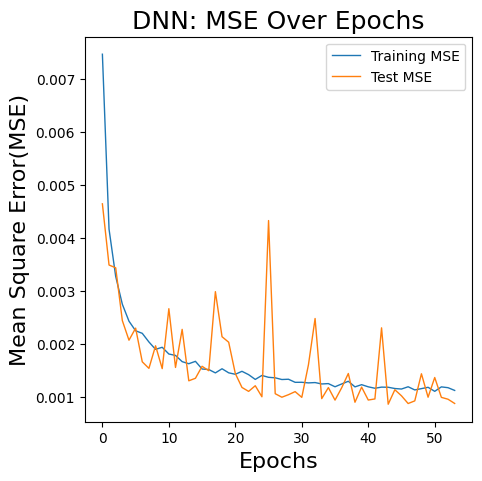

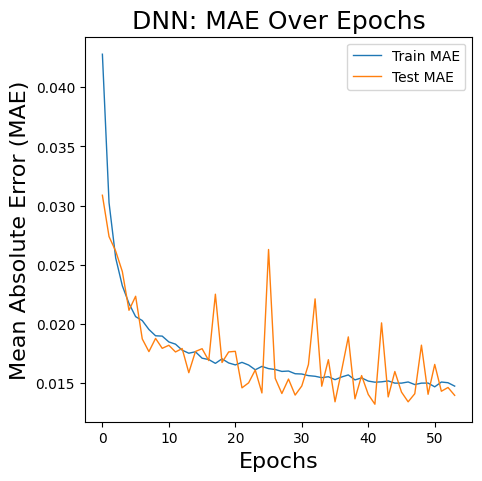

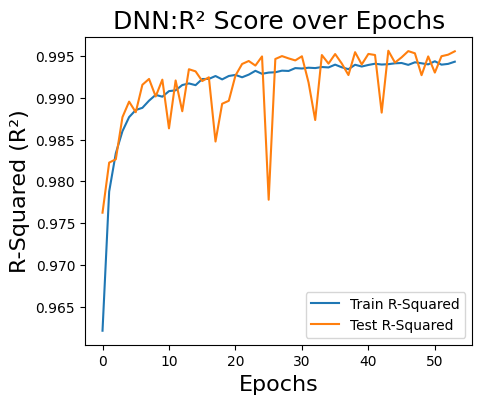

In [ ]:
# MSE over Epochs
plt.figure(figsize=(5,5))
plt.plot(history.history['loss'], label='Training MSE',lw = 1,)
plt.plot(history.history['val_loss'], label='Test MSE', lw = 1,)
plt.title('DNN: MSE Over Epochs', fontsize=18)
plt.ylabel('Mean Square Error(MSE)', fontsize=16)
plt.xlabel('Epochs', fontsize=16)
plt.legend()
plt.show()

# MAE over Epochs
plt.figure(figsize=(5, 5))
plt.plot(history.history['mean_absolute_error'], label='Train MAE', lw=1)
plt.plot(history.history['val_mean_absolute_error'], label='Test MAE', lw=1)
plt.title('DNN: MAE Over Epochs', fontsize=18)
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Mean Absolute Error (MAE)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

# R-Squared over Epochs
plt.figure(figsize=(5, 4))
plt.plot(history.history['coeff_determination'], label='Train R-Squared')
plt.plot(history.history['val_coeff_determination'], label='Test R-Squared')
plt.title('DNN:R² Score over Epochs', fontsize=18)
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('R-Squared (R²)', fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

n_estimators_list = list(range(10, 201, 10))
train_mse_rf, test_mse_rf = [], []
train_mae_rf, test_mae_rf = [], []
train_r2_rf, test_r2_rf = [], []

for n in n_estimators_list:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    train_mse_rf.append(mean_squared_error(y_train, y_train_pred))
    test_mse_rf.append(mean_squared_error(y_test, y_test_pred))
    
    train_mae_rf.append(mean_absolute_error(y_train, y_train_pred))
    test_mae_rf.append(mean_absolute_error(y_test, y_test_pred))
    
    train_r2_rf.append(r2_score(y_train, y_train_pred))
    test_r2_rf.append(r2_score(y_test, y_test_pred))


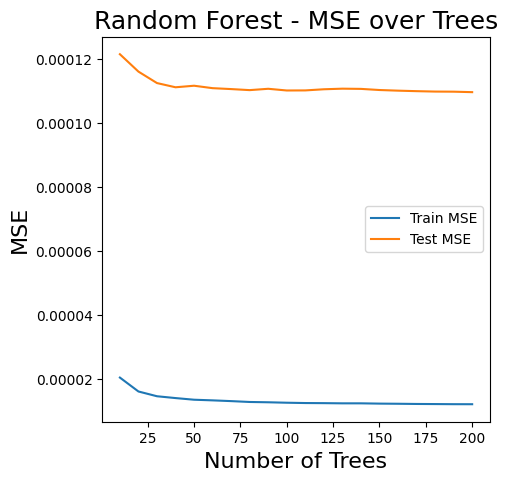

In [ ]:
# Plotting
plt.figure(figsize=(5,5))
plt.plot(n_estimators_list, train_mse_rf, label="Train MSE")
plt.plot(n_estimators_list, test_mse_rf, label="Test MSE")
plt.xlabel("Number of Trees",fontsize=16)
plt.ylabel("MSE",fontsize=16)
plt.title("Random Forest: MSE over Trees",fontsize=18)
plt.legend()

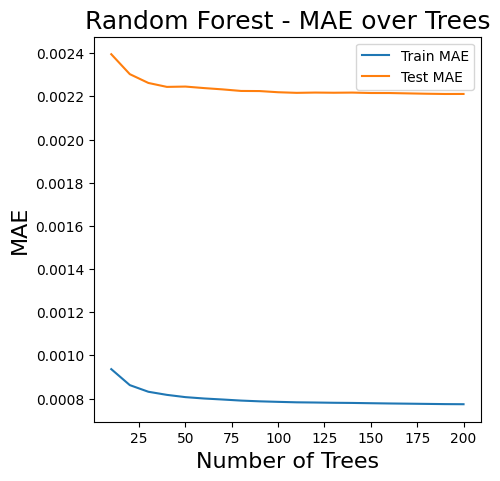

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(n_estimators_list, train_mae_rf, label="Train MAE")
plt.plot(n_estimators_list, test_mae_rf, label="Test MAE")
plt.xlabel("Number of Trees",fontsize=16)
plt.ylabel("MAE",fontsize=16)
plt.title("Random Forest: MAE over Trees",fontsize=18)
plt.legend()

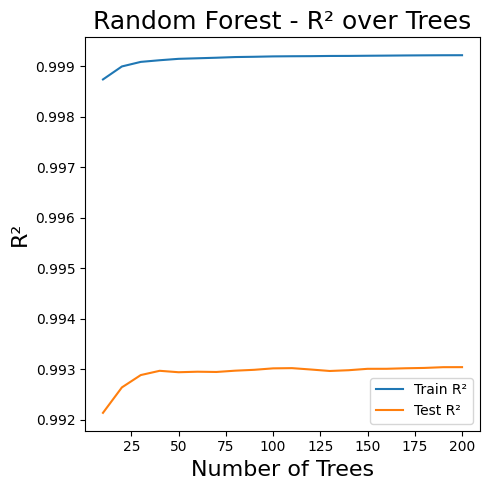

In [ ]:
plt.figure(figsize=(5, 5))
plt.plot(n_estimators_list, train_r2_rf, label="Train R²")
plt.plot(n_estimators_list, test_r2_rf, label="Test R²")
plt.xlabel("Number of Trees",fontsize=16)
plt.ylabel("R²",fontsize=16)
plt.title("Random Forest: R² over Trees",fontsize=18)
plt.legend()

plt.tight_layout()
plt.show()

#### Gradient Boosting Regression

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

n_estimators_list = list(range(10, 201, 10))
train_mse_gb, test_mse_gb = [], []
train_mae_gb, test_mae_gb = [], []
train_r2_gb, test_r2_gb = [], []

for n in n_estimators_list:
    base_gb = GradientBoostingRegressor(n_estimators=n, random_state=42)
    gb = MultiOutputRegressor(base_gb)
    gb.fit(X_train, y_train)
    
    y_train_pred = gb.predict(X_train)
    y_test_pred = gb.predict(X_test)
    
    train_mse_gb.append(mean_squared_error(y_train, y_train_pred))
    test_mse_gb.append(mean_squared_error(y_test, y_test_pred))
    
    train_mae_gb.append(mean_absolute_error(y_train, y_train_pred))
    test_mae_gb.append(mean_absolute_error(y_test, y_test_pred))
    
    train_r2_gb.append(r2_score(y_train, y_train_pred))
    test_r2_gb.append(r2_score(y_test, y_test_pred))


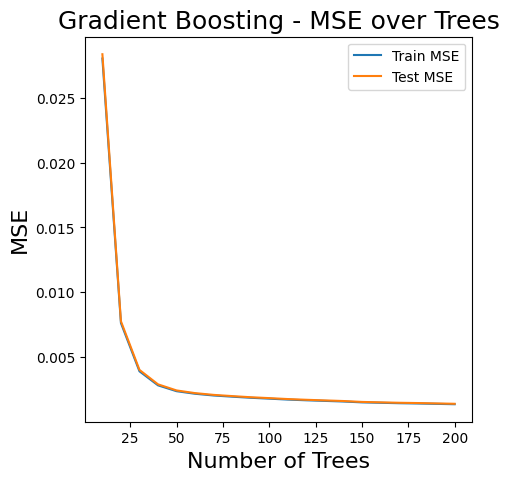

In [ ]:
# Plotting
plt.figure(figsize=(5, 5))
plt.plot(n_estimators_list, train_mse_gb, label="Train MSE")
plt.plot(n_estimators_list, test_mse_gb, label="Test MSE")
plt.xlabel("Number of Trees",fontsize=16)
plt.ylabel("MSE",fontsize=16)
plt.title("Gradient Boosting: MSE over Trees",fontsize=18)
plt.legend()
plt.show()

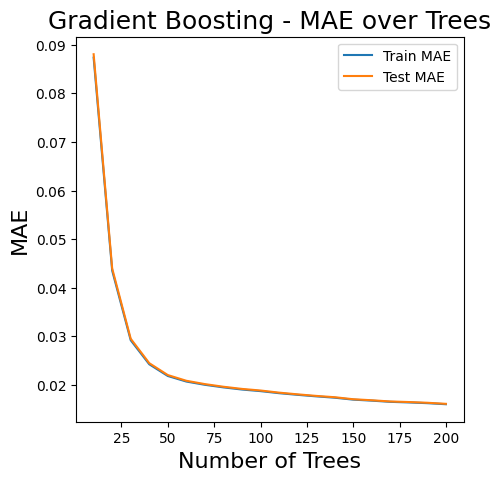

In [ ]:
plt.figure(figsize=(5, 5))
plt.plot(n_estimators_list, train_mae_gb, label="Train MAE")
plt.plot(n_estimators_list, test_mae_gb, label="Test MAE")
plt.xlabel("Number of Trees",fontsize=16)
plt.ylabel("MAE",fontsize=16)
plt.title("Gradient Boosting: MAE over Trees",fontsize=18)
plt.legend()
plt.show()


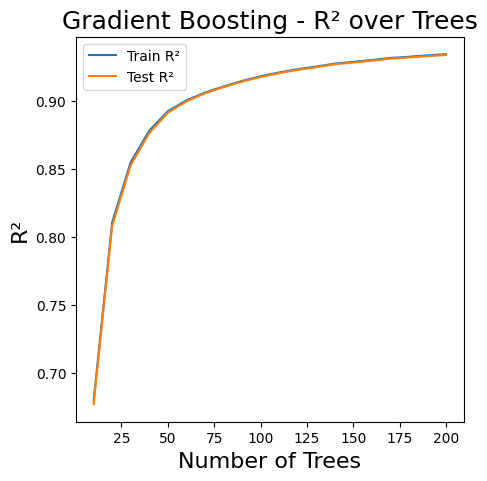

In [ ]:
plt.figure(figsize=(5, 5))
plt.plot(n_estimators_list, train_r2_gb, label="Train R²")
plt.plot(n_estimators_list, test_r2_gb, label="Test R²")
plt.xlabel("Number of Trees",fontsize=16)
plt.ylabel("R²",fontsize=16)
plt.title("Gradient Boosting: R² over Trees",fontsize=18)
plt.legend()
plt.show()

#### Multiple Polynomial Regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

degrees = list(range(1, 8))
train_mse_pr, test_mse_pr = [], []
train_mae_pr, test_mae_pr = [], []
train_r2_pr, test_r2_pr = [], []

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mse_pr.append(mean_squared_error(y_train, y_train_pred))
    test_mse_pr.append(mean_squared_error(y_test, y_test_pred))
    
    train_mae_pr.append(mean_absolute_error(y_train, y_train_pred))
    test_mae_pr.append(mean_absolute_error(y_test, y_test_pred))
    
    train_r2_pr.append(r2_score(y_train, y_train_pred))
    test_r2_pr.append(r2_score(y_test, y_test_pred))

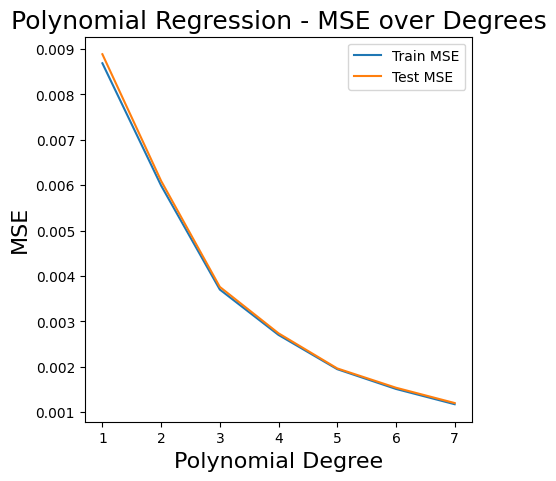

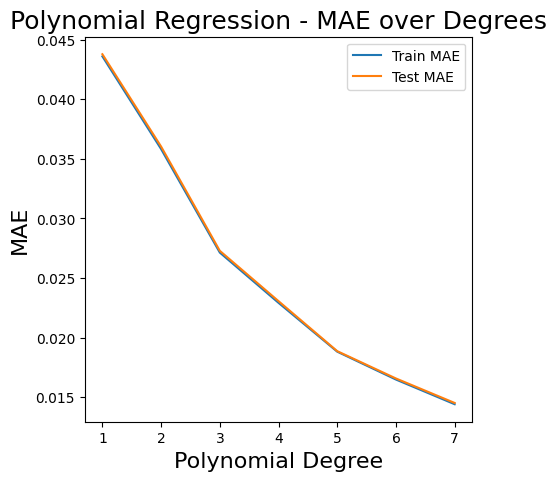

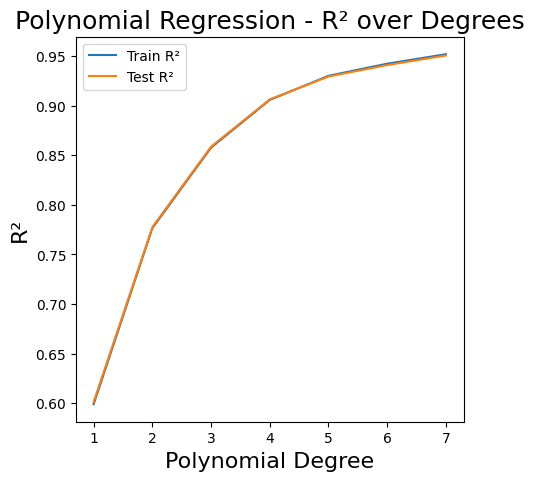

In [ ]:
# Plotting
plt.figure(figsize=(5, 5))
plt.plot(degrees, train_mse_pr, label="Train MSE")
plt.plot(degrees, test_mse_pr, label="Test MSE")
plt.xlabel("Polynomial Degree",fontsize=16)
plt.ylabel("MSE",fontsize=16)
plt.title("Polynomial Regression: MSE over Degrees",fontsize=18)
plt.legend()
plt.show()

plt.figure(figsize=(5, 5))
plt.plot(degrees, train_mae_pr, label="Train MAE")
plt.plot(degrees, test_mae_pr, label="Test MAE")
plt.xlabel("Polynomial Degree",fontsize=16)
plt.ylabel("MAE",fontsize=16)
plt.title("Polynomial Regression: MAE over Degrees",fontsize=18)
plt.legend()
plt.show()

plt.figure(figsize=(5, 5))
plt.plot(degrees, train_r2_pr, label="Train R²")
plt.plot(degrees, test_r2_pr, label="Test R²")
plt.xlabel("Polynomial Degree",fontsize=16)
plt.ylabel("R²",fontsize=16)
plt.title("Polynomial Regression: R² over Degrees",fontsize=18)
plt.legend()
plt.show()
plt.show()

# 7. Plot: Predicted vs True Values

#### Deep Neural Networks

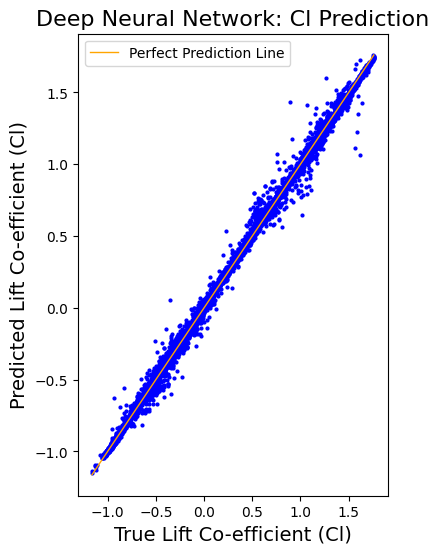

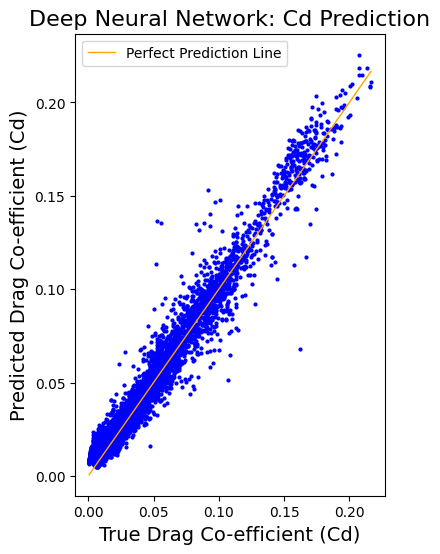

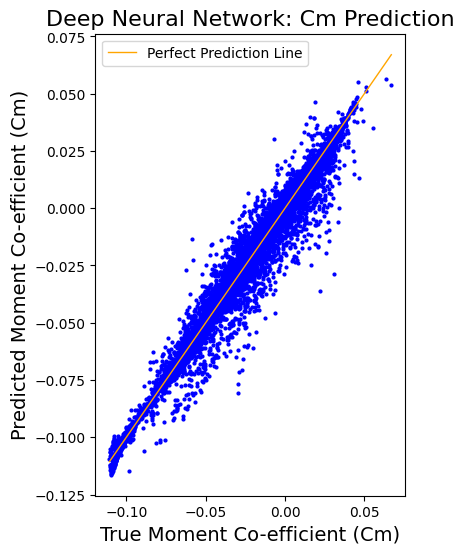

In [ ]:
# Predicted Cl vs True Cl
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cl'], y_pred_test_dnn[:, 0], color='blue', s=4) 
plt.plot([min(y_test['Cl']), max(y_test['Cl'])], 
         [min(y_test['Cl']), max(y_test['Cl'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Deep Neural Network: Cl Prediction', fontsize=16)
plt.xlabel('True Lift Co-efficient (Cl)', fontsize=14)
plt.ylabel('Predicted Lift Co-efficient (Cl)', fontsize=14)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cd vs True Cd
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cd'], y_pred_test_dnn[:, 1], color='blue', s=4)
plt.plot([min(y_test['Cd']), max(y_test['Cd'])], 
         [min(y_test['Cd']), max(y_test['Cd'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Deep Neural Network: Cd Prediction', fontsize=16)
plt.xlabel('True Drag Co-efficient (Cd)', fontsize=14)
plt.ylabel('Predicted Drag Co-efficient (Cd)', fontsize=14)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cm vs True Cm
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cm'], y_pred_test_dnn[:, 2], color='blue', s=4)
plt.plot([min(y_test['Cm']), max(y_test['Cm'])], 
         [min(y_test['Cm']), max(y_test['Cm'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Deep Neural Network: Cm Prediction', fontsize=16)
plt.xlabel('True Moment Co-efficient (Cm)', fontsize=14)
plt.ylabel('Predicted Moment Co-efficient (Cm)', fontsize=14)
plt.legend()
plt.grid(False)
plt.show()

#### Random Forest

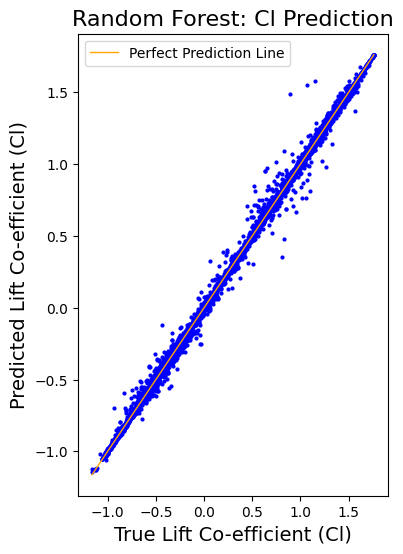

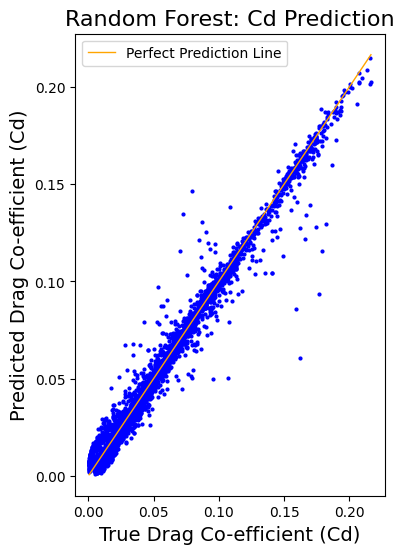

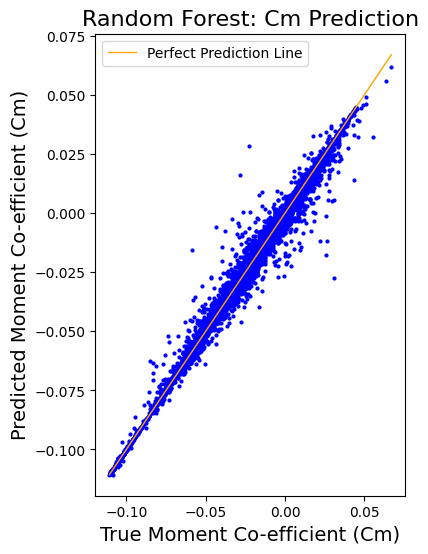

In [ ]:
# Predicted Cl vs True Cl
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cl'], y_pred_test_rf[:, 0], color='blue', s=4)  
plt.plot([min(y_test['Cl']), max(y_test['Cl'])], 
         [min(y_test['Cl']), max(y_test['Cl'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Random Forest: Cl Prediction', fontsize=16)
plt.xlabel('True Lift Co-efficient (Cl)', fontsize=14)
plt.ylabel('Predicted Lift Co-efficient (Cl)', fontsize=14)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cd vs True Cd
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cd'], y_pred_test_rf[:, 1], color='blue', s=4) 
plt.plot([min(y_test['Cd']), max(y_test['Cd'])], 
         [min(y_test['Cd']), max(y_test['Cd'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Random Forest: Cd Prediction', fontsize=16)
plt.xlabel('True Drag Co-efficient (Cd)', fontsize=14)
plt.ylabel('Predicted Drag Co-efficient (Cd)', fontsize=14)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cm vs True Cm
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cm'], y_pred_test_rf[:, 2], color='blue', s=4)
plt.plot([min(y_test['Cm']), max(y_test['Cm'])], 
         [min(y_test['Cm']), max(y_test['Cm'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Random Forest: Cm Prediction', fontsize=16)
plt.xlabel('True Moment Co-efficient (Cm)', fontsize=14)
plt.ylabel('Predicted Moment Co-efficient (Cm)', fontsize=14)
plt.legend()
plt.grid(False)
plt.show()

#### Gradient Boosting

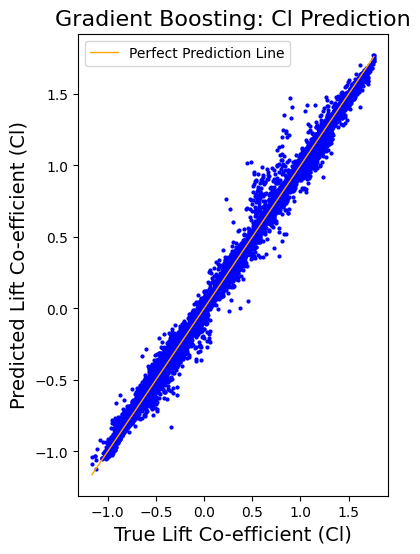

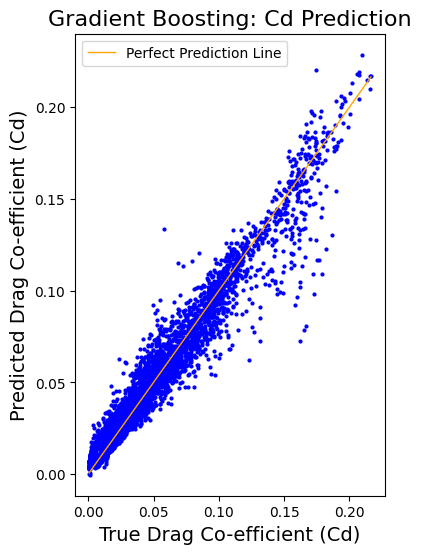

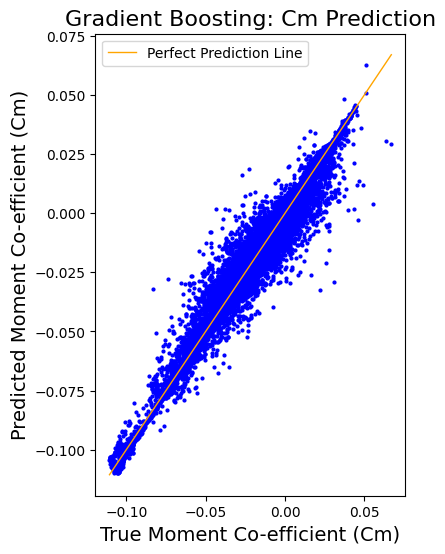

In [ ]:
# Predicted Cl vs True Cl
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cl'], y_pred_test_gb[:, 0], color='blue', s=4)  
plt.plot([min(y_test['Cl']), max(y_test['Cl'])], 
         [min(y_test['Cl']), max(y_test['Cl'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Gradient Boosting: Cl Prediction', fontsize=16)
plt.xlabel('True Lift Co-efficient (Cl)', fontsize=14)
plt.ylabel('Predicted Lift Co-efficient (Cl)', fontsize=14)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cd vs True Cd
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cd'], y_pred_test_gb[:, 1], color='blue', s=4) 
plt.plot([min(y_test['Cd']), max(y_test['Cd'])], 
         [min(y_test['Cd']), max(y_test['Cd'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Gradient Boosting: Cd Prediction', fontsize=16)
plt.xlabel('True Drag Co-efficient (Cd)', fontsize=14)
plt.ylabel('Predicted Drag Co-efficient (Cd)', fontsize=14)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cm vs True Cm
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cm'], y_pred_test_gb[:, 2], color='blue', s=4)
plt.plot([min(y_test['Cm']), max(y_test['Cm'])], 
         [min(y_test['Cm']), max(y_test['Cm'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Gradient Boosting: Cm Prediction', fontsize=16)
plt.xlabel('True Moment Co-efficient (Cm)', fontsize=14)
plt.ylabel('Predicted Moment Co-efficient (Cm)', fontsize=14)
plt.legend()
plt.grid(False)
plt.show()

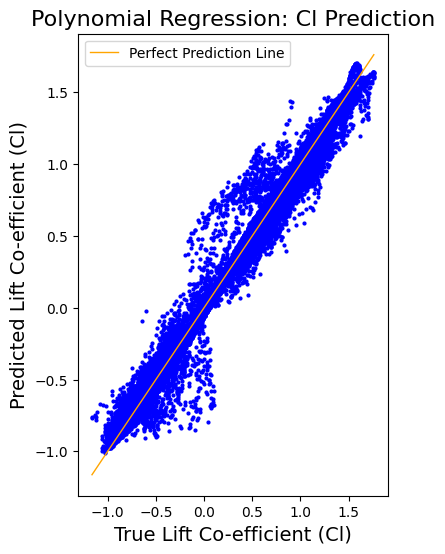

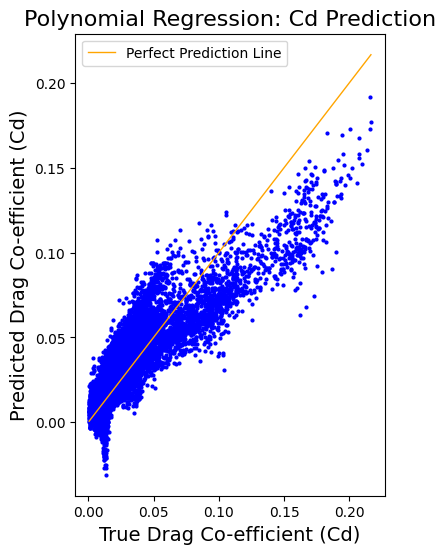

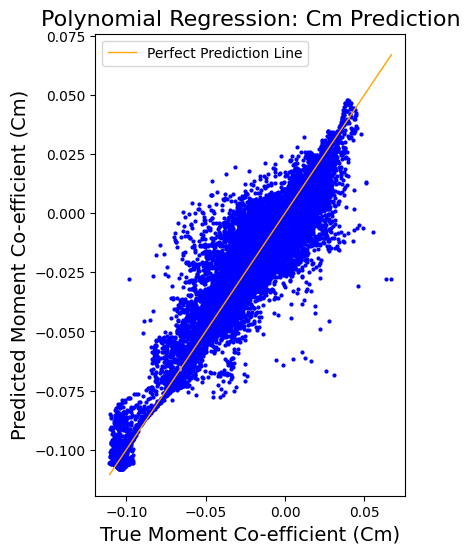

In [ ]:
# Predicted Cl vs True Cl
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cl'], y_pred_test_poly[:, 0], color='blue', s=4)  
plt.plot([min(y_test['Cl']), max(y_test['Cl'])], 
         [min(y_test['Cl']), max(y_test['Cl'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Polynomial Regression: Cl Prediction', fontsize=16)
plt.xlabel('True Lift Co-efficient (Cl)', fontsize=14)
plt.ylabel('Predicted Lift Co-efficient (Cl)', fontsize=14)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cd vs True Cd
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cd'], y_pred_test_poly[:, 1], color='blue', s=4) 
plt.plot([min(y_test['Cd']), max(y_test['Cd'])], 
         [min(y_test['Cd']), max(y_test['Cd'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Polynomial Regression: Cd Prediction', fontsize=16)
plt.xlabel('True Drag Co-efficient (Cd)', fontsize=14)
plt.ylabel('Predicted Drag Co-efficient (Cd)', fontsize=14)
plt.legend()
plt.grid(False)
plt.show()

# Predicted Cm vs True Cm
plt.figure(figsize=(4, 6))
plt.scatter(y_test['Cm'], y_pred_test_poly[:, 2], color='blue', s=4)
plt.plot([min(y_test['Cm']), max(y_test['Cm'])], 
         [min(y_test['Cm']), max(y_test['Cm'])], 
         color='orange', lw=1, label='Perfect Prediction Line')
plt.title('Polynomial Regression: Cm Prediction', fontsize=16)
plt.xlabel('True Moment Co-efficient (Cm)', fontsize=14)
plt.ylabel('Predicted Moment Co-efficient (Cm)', fontsize=14)
plt.legend()
plt.grid(False)
plt.show()

# 8. Feature Importance

#### Deep Neural Networks


Cl Prediction

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

# Define a wrapper to make your Keras model compatible with sklearn
class ANNWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self

    def predict(self, X):
        # Predict only one output at a time for permutation importance
        return self.model.predict(X).reshape(-1, 3)

# Instantiate the wrapper
wrapped_model = ANNWrapper(dnn)

# Select which output to evaluate feature importance for (0 = Cl, 1 = Cd, 2 = Cm)
target_index = 0  # Change to 1 or 2 for Cd or Cm

# Compute permutation importance
def custom_scorer(estimator, X, y):
    y_pred = estimator.predict(X)[:, target_index]
    y_true = y.iloc[:, target_index] if isinstance(y, pd.DataFrame) else y[:, target_index]
    return -mean_squared_error(y_true, y_pred)  # negative MSE for scoring

result = permutation_importance(
    wrapped_model, X_test, y_test,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer
)

# Prepare the feature names and importance
importance = result.importances_mean
feature_names = X.columns

# Sort features by importance
sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]


696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step
696/696 ━━━

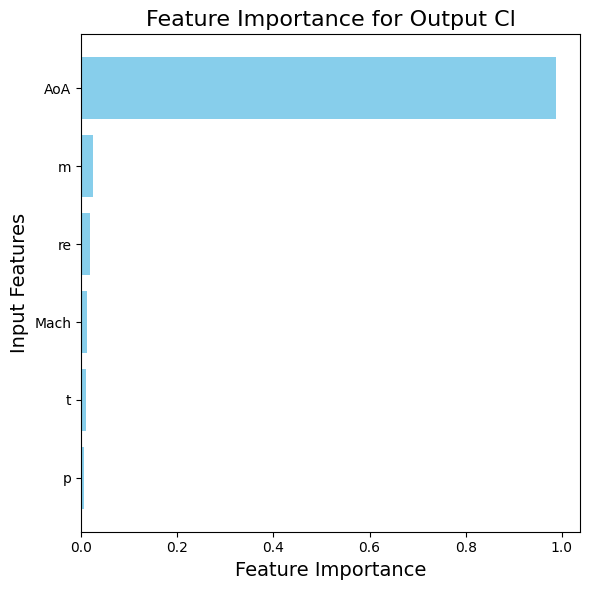

In [ ]:
# Plotting
plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Input Features', fontsize=14)
plt.title(f'Feature Importance for Output {["Cl", "Cd", "Cm"][target_index]}', fontsize=16)
plt.grid(False) # , linestyle='--', linewidth=0.5
plt.tight_layout()
plt.show()

Cd Prediction

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

# Define a wrapper to make your Keras model compatible with sklearn
class ANNWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self

    def predict(self, X):
        # Predict only one output at a time for permutation importance
        return self.model.predict(X).reshape(-1, 3)

# Instantiate the wrapper
wrapped_model = ANNWrapper(dnn)

# Select which output to evaluate feature importance for (0 = Cl, 1 = Cd, 2 = Cm)
target_index = 1  # Change to 1 or 2 for Cd or Cm

# Compute permutation importance
def custom_scorer(estimator, X, y):
    y_pred = estimator.predict(X)[:, target_index]
    y_true = y.iloc[:, target_index] if isinstance(y, pd.DataFrame) else y[:, target_index]
    return -mean_squared_error(y_true, y_pred)  # negative MSE for scoring

result = permutation_importance(
    wrapped_model, X_test, y_test,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer
)

# Prepare the feature names and importance
importance = result.importances_mean
feature_names = X.columns

# Sort features by importance
sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]



696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step
696/696 ━━━

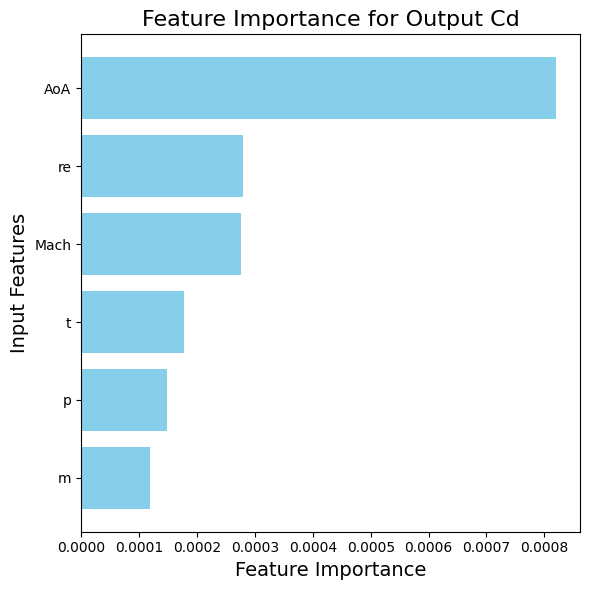

In [ ]:
# Plotting
plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Input Features', fontsize=14)
plt.title(f'Feature Importance for Output {["Cl", "Cd", "Cm"][target_index]}', fontsize=16)
plt.grid(False) # , linestyle='--', linewidth=0.5
plt.tight_layout()
plt.show()


Cm Prediction

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

# Define a wrapper to make your Keras model compatible with sklearn
class ANNWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self

    def predict(self, X):
        # Predict only one output at a time for permutation importance
        return self.model.predict(X).reshape(-1, 3)

# Instantiate the wrapper
wrapped_model = ANNWrapper(dnn)

# Select which output to evaluate feature importance for (0 = Cl, 1 = Cd, 2 = Cm)
target_index = 2  # Change to 1 or 2 for Cd or Cm

# Compute permutation importance
def custom_scorer(estimator, X, y):
    y_pred = estimator.predict(X)[:, target_index]
    y_true = y.iloc[:, target_index] if isinstance(y, pd.DataFrame) else y[:, target_index]
    return -mean_squared_error(y_true, y_pred)  # negative MSE for scoring

result = permutation_importance(
    wrapped_model, X_test, y_test,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer
)

# Prepare the feature names and importance
importance = result.importances_mean
feature_names = X.columns

# Sort features by importance
sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step
696/696 ━━━

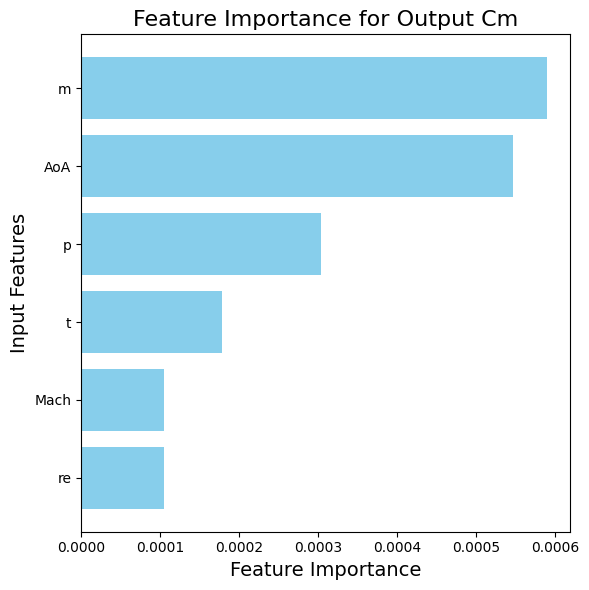

In [ ]:
# Plotting
plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Input Features', fontsize=14)
plt.title(f'Feature Importance for Output {["Cl", "Cd", "Cm"][target_index]}', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


#### Random Forest

Cl Prediction

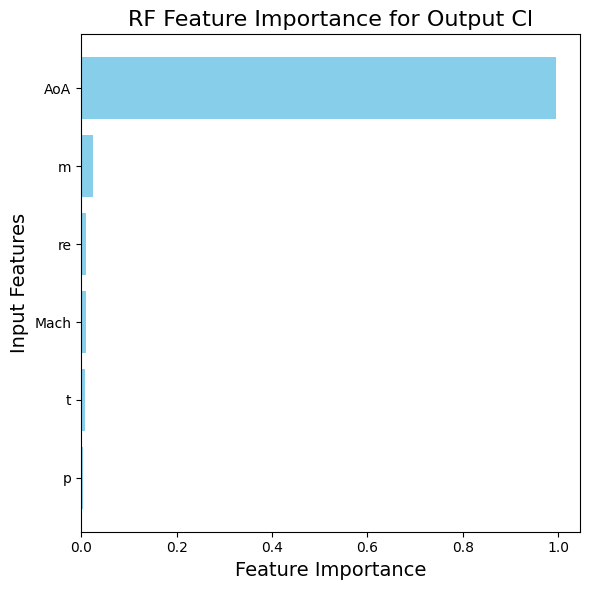

In [ ]:
from sklearn.inspection import permutation_importance

# Choose output (0 = Cl, 1 = Cd, 2 = Cm)
target_index = 0

# Updated custom scorer
def custom_scorer_rf(estimator, X, y):
    y_pred = estimator.predict(X)
    
    if isinstance(y, pd.DataFrame):
        y_true = y.iloc[:, target_index]
        y_pred = y_pred[:, target_index]
    else:
        y_true = y[:, target_index]
        y_pred = y_pred[:, target_index]
        
    return -mean_squared_error(y_true, y_pred)

# Compute permutation importance
rf_result = permutation_importance(
    rf, X_test, y_test,  # use your trained RF model here
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_rf
)

# Prepare data
importance = rf_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

# Plot
plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Input Features', fontsize=14)
plt.title(f'RF Feature Importance for Output {["Cl", "Cd", "Cm"][target_index]}', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


Cd Prediction

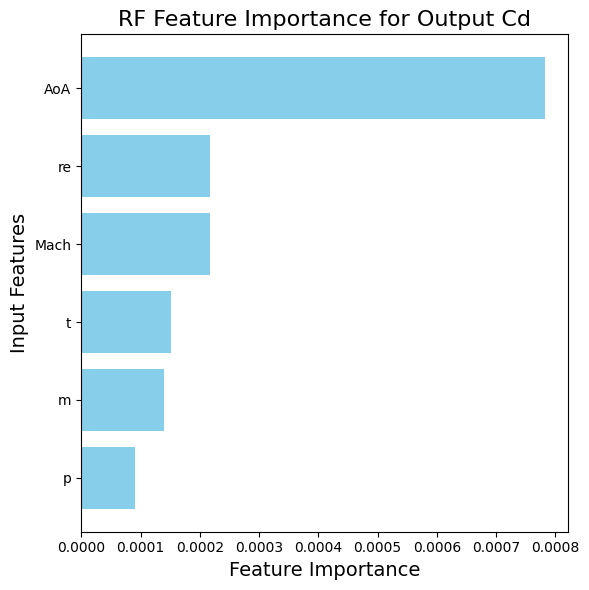

In [ ]:
from sklearn.inspection import permutation_importance

# Choose output (0 = Cl, 1 = Cd, 2 = Cm)
target_index = 1

# Updated custom scorer
def custom_scorer_rf(estimator, X, y):
    y_pred = estimator.predict(X)
    
    if isinstance(y, pd.DataFrame):
        y_true = y.iloc[:, target_index]
        y_pred = y_pred[:, target_index]
    else:
        y_true = y[:, target_index]
        y_pred = y_pred[:, target_index]
        
    return -mean_squared_error(y_true, y_pred)

# Compute permutation importance
rf_result = permutation_importance(
    rf, X_test, y_test,  # use your trained RF model here
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_rf
)

# Prepare data
importance = rf_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

# Plot
plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Input Features', fontsize=14)
plt.title(f'RF Feature Importance for Output {["Cl", "Cd", "Cm"][target_index]}', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


Cm Prediction

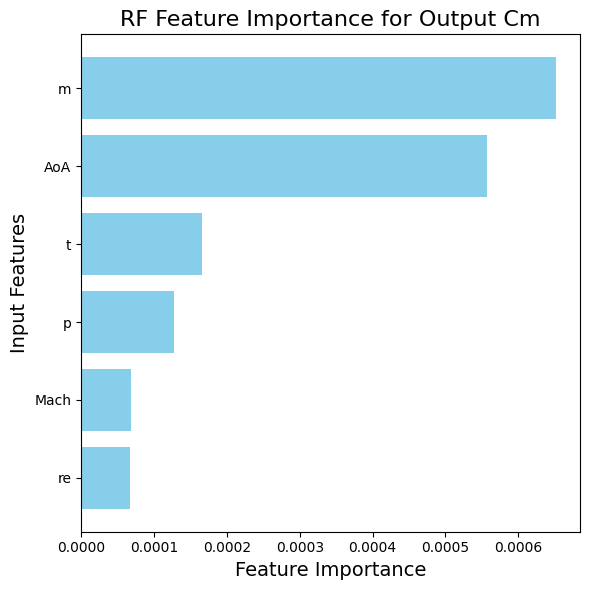

In [ ]:
from sklearn.inspection import permutation_importance

# Choose output (0 = Cl, 1 = Cd, 2 = Cm)
target_index = 2

# Updated custom scorer
def custom_scorer_rf(estimator, X, y):
    y_pred = estimator.predict(X)
    
    if isinstance(y, pd.DataFrame):
        y_true = y.iloc[:, target_index]
        y_pred = y_pred[:, target_index]
    else:
        y_true = y[:, target_index]
        y_pred = y_pred[:, target_index]
        
    return -mean_squared_error(y_true, y_pred)

# Compute permutation importance
rf_result = permutation_importance(
    rf, X_test, y_test,  # use your trained RF model here
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_rf
)

# Prepare data
importance = rf_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

# Plot
plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Input Features', fontsize=14)
plt.title(f'RF Feature Importance for Output {["Cl", "Cd", "Cm"][target_index]}', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


#### Gradient Boosting

Cl Predition

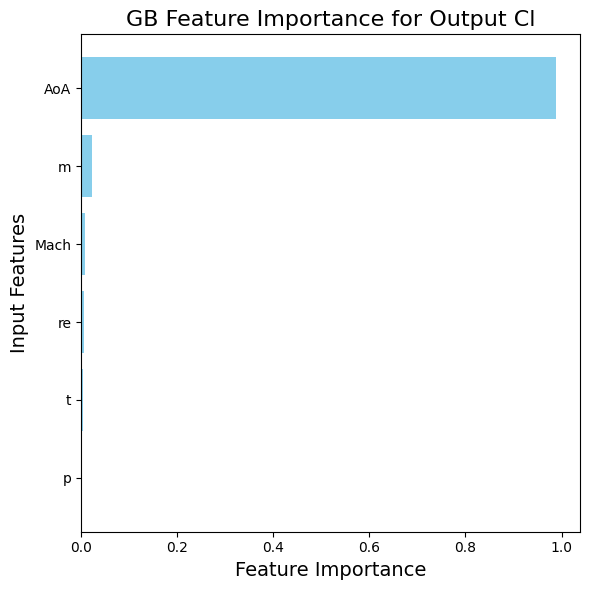

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this index to 0 (Cl), 1 (Cd), or 2 (Cm) as needed
target_index = 0  # 0 = Cl, 1 = Cd, 2 = Cm

# Ensure y_test is a NumPy array for slicing
if isinstance(y_test, pd.DataFrame):
    y_test_array = y_test.values
else:
    y_test_array = y_test

def custom_scorer_gb(estimator, X, y):
    y_pred = estimator.predict(X)
    return -mean_squared_error(y[:, target_index], y_pred[:, target_index])

gb_result = permutation_importance(
    gb, X_test, y_test_array,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_gb
)

importance = gb_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Input Features', fontsize=14)
plt.title(f'GB Feature Importance for Output {["Cl", "Cd", "Cm"][target_index]}', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


Cd Prediction

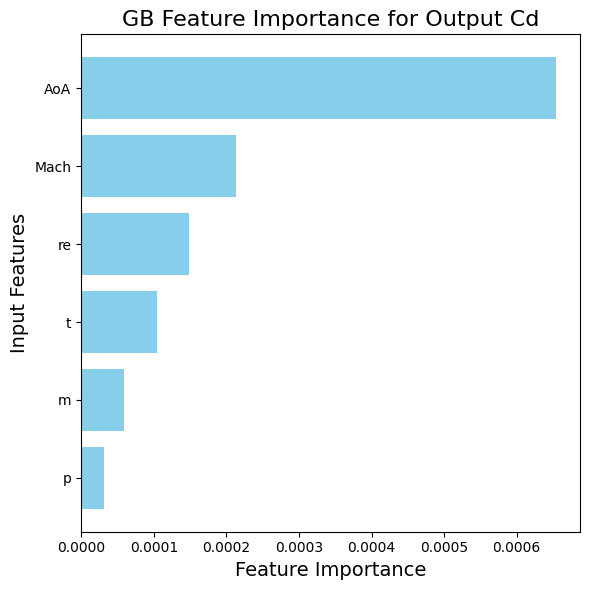

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this index to 0 (Cl), 1 (Cd), or 2 (Cm) as needed
target_index = 1  # 0 = Cl, 1 = Cd, 2 = Cm

# Ensure y_test is a NumPy array for slicing
if isinstance(y_test, pd.DataFrame):
    y_test_array = y_test.values
else:
    y_test_array = y_test

def custom_scorer_gb(estimator, X, y):
    y_pred = estimator.predict(X)
    return -mean_squared_error(y[:, target_index], y_pred[:, target_index])

gb_result = permutation_importance(
    gb, X_test, y_test_array,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_gb
)

importance = gb_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Input Features', fontsize=14)
plt.title(f'GB Feature Importance for Output {["Cl", "Cd", "Cm"][target_index]}', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


Cm Prediction

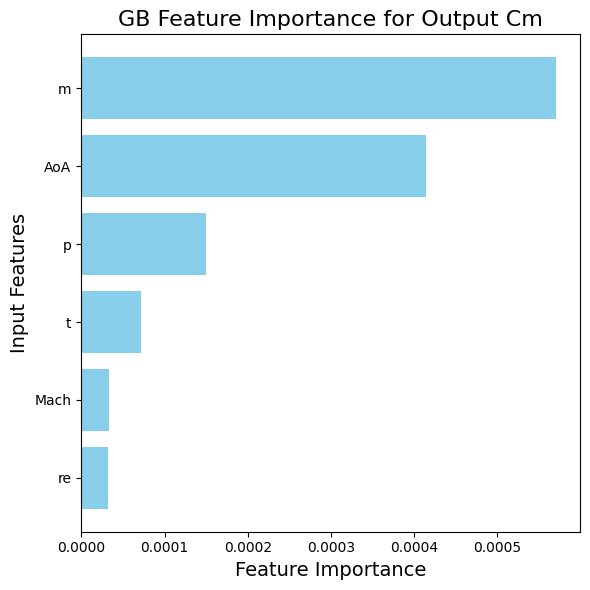

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this index to 0 (Cl), 1 (Cd), or 2 (Cm) as needed
target_index = 2  # 0 = Cl, 1 = Cd, 2 = Cm

# Ensure y_test is a NumPy array for slicing
if isinstance(y_test, pd.DataFrame):
    y_test_array = y_test.values
else:
    y_test_array = y_test

def custom_scorer_gb(estimator, X, y):
    y_pred = estimator.predict(X)
    return -mean_squared_error(y[:, target_index], y_pred[:, target_index])

gb_result = permutation_importance(
    gb, X_test, y_test_array,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_gb
)

importance = gb_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Input Features', fontsize=14)
plt.title(f'GB Feature Importance for Output {["Cl", "Cd", "Cm"][target_index]}', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


#### Polynomial Regression

Cl Prediction

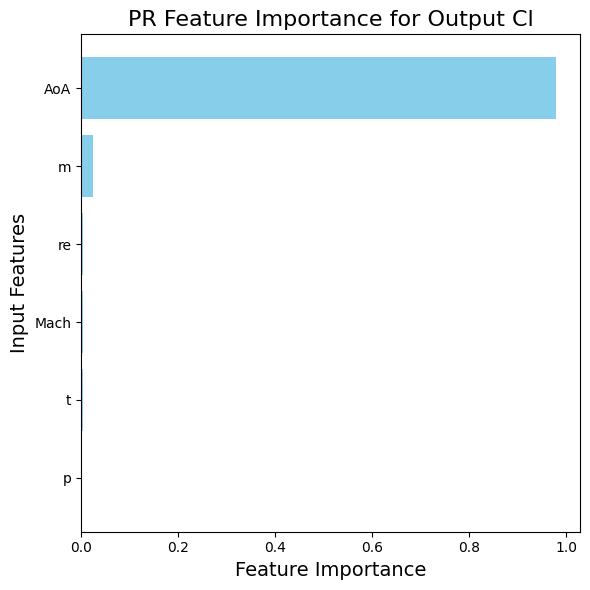

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this index to 0 (Cl), 1 (Cd), or 2 (Cm) as needed
target_index = 0  # 0 = Cl, 1 = Cd, 2 = Cm

# Ensure y_test is a NumPy array for slicing
if isinstance(y_test, pd.DataFrame):
    y_test_array = y_test.values
else:
    y_test_array = y_test

def custom_scorer_pr(estimator, X, y):
    y_pred = estimator.predict(X)
    return -mean_squared_error(y[:, target_index], y_pred[:, target_index])

pr_result = permutation_importance(
    poly, X_test, y_test_array,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_pr
)

importance = pr_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Input Features', fontsize=14)
plt.title(f'PR Feature Importance for Output {["Cl", "Cd", "Cm"][target_index]}', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


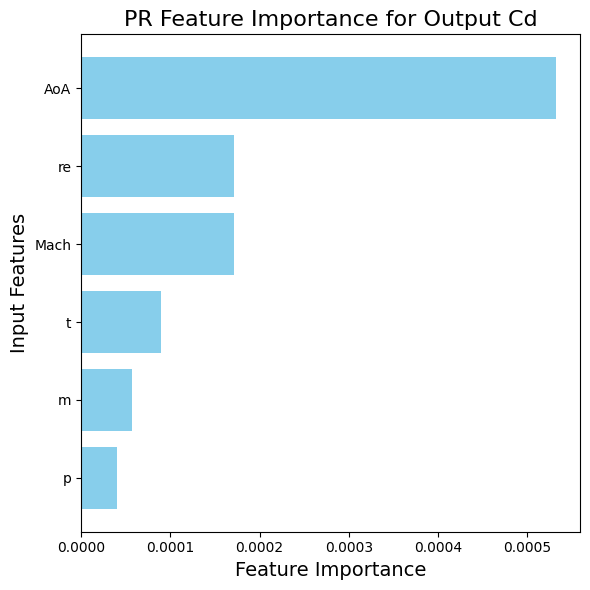

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this index to 0 (Cl), 1 (Cd), or 2 (Cm) as needed
target_index = 1  # 0 = Cl, 1 = Cd, 2 = Cm

# Ensure y_test is a NumPy array for slicing
if isinstance(y_test, pd.DataFrame):
    y_test_array = y_test.values
else:
    y_test_array = y_test

def custom_scorer_pr(estimator, X, y):
    y_pred = estimator.predict(X)
    return -mean_squared_error(y[:, target_index], y_pred[:, target_index])

pr_result = permutation_importance(
    poly, X_test, y_test_array,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_pr
)

importance = pr_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Input Features', fontsize=14)
plt.title(f'PR Feature Importance for Output {["Cl", "Cd", "Cm"][target_index]}', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


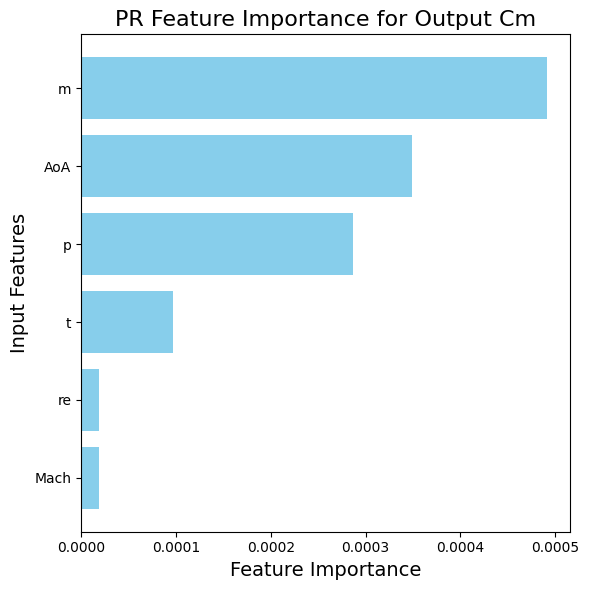

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this index to 0 (Cl), 1 (Cd), or 2 (Cm) as needed
target_index = 2  # 0 = Cl, 1 = Cd, 2 = Cm

# Ensure y_test is a NumPy array for slicing
if isinstance(y_test, pd.DataFrame):
    y_test_array = y_test.values
else:
    y_test_array = y_test

def custom_scorer_pr(estimator, X, y):
    y_pred = estimator.predict(X)
    return -mean_squared_error(y[:, target_index], y_pred[:, target_index])

pr_result = permutation_importance(
    poly, X_test, y_test_array,
    n_repeats=10,
    random_state=0,
    scoring=custom_scorer_pr
)

importance = pr_result.importances_mean
feature_names = X.columns

sorted_indices = np.argsort(importance)
sorted_importance = importance[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(6, 6))
plt.barh(sorted_feature_names, sorted_importance, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Input Features', fontsize=14)
plt.title(f'PR Feature Importance for Output {["Cl", "Cd", "Cm"][target_index]}', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


In [ ]:
# # Example input: [m, p, t, Mach, re, AoA]
# new_condition = np.array([[0.03, 0.3, 0.09, 0.000435, 10000, 11.5]])  # Replace values with your desired condition

# # Scale the input using the same scaler used during training
# new_condition_scaled = sc.transform(new_condition)

# # Predict Cl, Cd, Cm
# predicted_output = dnn.predict(new_condition_scaled)

# # Extract the values
# predicted_Cl = predicted_output[0][0]
# predicted_Cd = predicted_output[0][1]
# predicted_Cm = predicted_output[0][2]

# # Print the results
# print(f"Predicted Cl: {predicted_Cl:.5f}")
# print(f"Predicted Cd: {predicted_Cd:.5f}")
# print(f"Predicted Cm: {predicted_Cm:.5f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted Cl: 0.62295
Predicted Cd: 0.14680
Predicted Cm: -0.08321


d:\NIHUT NAMAZ\Airfoil\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
